### PGCB Hourly Generation Dataset (Bangladesh)
This dataset, published by the Power Grid Company of Bangladesh (PGCB), provides hourly records of electricity generation, demand, and loadshedding across the national grid.<br>
Source: https://archive.ics.uci.edu/dataset/1175/pgcb+hourly+generation+dataset+(bangladesh)<br>
The target value is : demand_mw

In [46]:
# LIST Of TASKS:
# Use at least 2 feature selection tools
# Check redundancy and multicollinearity
# Remove features only if justified
# Create at least one type of new feature
# Try DFS or interaction features or cluster profiling
# Try PCA if useful
# Handle high-cardinality features if needed
# Re-analyze after feature engineering
# Compare original vs modified dataset
# Judge realism and usefulness

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

from sklearn.feature_selection import mutual_info_regression, SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.linear_model import Ridge
from statsmodels.stats.outliers_influence import variance_inflation_factor
import phik

from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer


<h3><center>Exploring and Understand the DS<h3>

In [48]:
df = pd.read_excel("Datasets/PGCB_date_power_demand.xlsx")
df['datetime']=pd.to_datetime(df['datetime'])
df= df.sort_values('datetime').reset_index(drop=True)
df.head()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 00:00:00,4821.0,4821,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,2015-04-19 01:00:00,3612.0,3612,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,2015-04-19 02:00:00,3727.0,3727,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
3,2015-04-19 03:00:00,3632.0,3632,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
4,2015-04-19 04:00:00,3641.0,3641,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN


In [49]:
# later I will use this for comparison after optimization.
df_original = df.copy()

In [50]:
df.info()
# The ds shape is 92650 records and 15 columns.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92650 entries, 0 to 92649
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime              92650 non-null  datetime64[ns]
 1   generation_mw         92650 non-null  float64       
 2   demand_mw             92650 non-null  int64         
 3   load_shedding         92650 non-null  int64         
 4   gas                   92650 non-null  int64         
 5   liquid_fuel           92650 non-null  int64         
 6   coal                  92650 non-null  int64         
 7   hydro                 92650 non-null  int64         
 8   solar                 70517 non-null  float64       
 9   wind                  18676 non-null  float64       
 10  india_bheramara_hvdc  92650 non-null  int64         
 11  india_tripura         92650 non-null  int64         
 12  india_adani           7338 non-null   float64       
 13  nepal           

In [51]:
# Let's check the missing value
df.isnull().sum().sort_values(ascending=False) 

nepal                   87299
remarks                 86257
india_adani             85312
wind                    73974
solar                   22133
datetime                    0
generation_mw               0
demand_mw                   0
load_shedding               0
gas                         0
liquid_fuel                 0
coal                        0
hydro                       0
india_bheramara_hvdc        0
india_tripura               0
dtype: int64

In [52]:
# The ds has a lot of missing values.
# wind, india_bheram, india_adani and nepal columns have  missing values more than half of the ds. 
# let me check wind missing values by year. 
df.groupby(df['datetime'].dt.year)['wind'].apply(lambda x: x.notna().sum()).sort_values(ascending=False)

datetime
2024    9148
2023    5340
2025    4188
2015       0
2016       0
2017       0
2018       0
2019       0
2020       0
2021       0
2022       0
Name: wind, dtype: int64

In [53]:
# let's check the time range of the data. 
print(df['datetime'].min())
print(df['datetime'].max())
# the time range is almost 10 years
# 92650/8760 is around 10.5 years

2015-04-19 00:00:00
2025-06-17 12:00:00


In [54]:
# the ds mixes hourly and half hourly intervals
gaps_hourly = df['datetime'].diff().value_counts().head(5)
gaps_hourly
# 83 K hours gaps and around 8k half hourly gaps.
# I need to resample to hourly and handle the hourly gaps.

datetime
0 days 01:00:00    83649
0 days 00:30:00     8336
0 days 00:00:00      432
0 days 02:00:00      178
0 days 03:00:00       11
Name: count, dtype: int64

In [55]:
df[['demand_mw','generation_mw','gas','coal','solar']].describe().round(0)
# The max value of generation mw is 64 million. this is a huge number, kind of impossible.
# The values can be entered wrongly, or the dot is missing. 
# the median is 8412 and 75% is around 10550 and suddenly the max jumps to  64 million. 
# Now I am sure that the max value is completely wrong.
# Peak values of solar is during the day time, which is correct.
# Same issue with Demand mw, the max value does not make sense. 

# Gas is the most used energy source. 

,demand_mw,generation_mw,gas,coal,solar
count,92650.0,92650.0,92650.0,92650.0,70517.0
mean,8820.0,9429.0,5121.0,974.0,46.0
std,2772.0,211976.0,1139.0,1227.0,106.0
min,6.0,73.0,0.0,0.0,0.0
25%,6812.0,6815.0,4419.0,159.0,0.0
50%,8422.0,8412.0,5022.0,401.0,0.0
75%,10633.0,10556.0,5812.0,1220.0,25.0
max,156050.0,64526500.0,74818.0,31687.0,2998.0


In [56]:
# I asked google AI moode; Bangladesh's electricity demand peaks around?
# The response:  16,000–18,000 MW

# let me see the suspicious rows where the demand_mw is above 20000 mw
suspicious_rows = df[df['demand_mw']>20000][['datetime', 'demand_mw', 'generation_mw']]
suspicious_rows
# As I said in above cell, the demand_mw has the same issue as generation_mw. 
# demand energy is 10 times bigger than generation energy.

,datetime,demand_mw,generation_mw
18997,2017-05-17 12:00:00,74223,7423.0
21516,2017-08-26 15:00:00,80689,8068.0
33384,2018-12-18 08:00:00,55639,5563.9
71237,2023-02-11 18:30:00,104860,10052.0
72887,2023-04-18 18:30:00,156050,15172.0
77101,2023-10-04 09:00:00,20587,10587.0
77268,2023-10-11 03:00:00,117000,11468.0
81971,2024-04-16 07:00:00,121000,11701.0
83919,2024-07-03 05:00:00,111140,11080.0


### Data cleaning

In [57]:
# I can drop suspicious rows for demand
df = df[~df.index.isin(suspicious_rows.index)]

# I dont need to drop the max generation mw value, I am going to drop the column later.
# Because it is close to the target in time and meaning
# Same for load shedding, 

# Drop the empty columns with leakages 
df = df.drop(['remarks','nepal','india_adani','wind','generation_mw','load_shedding'], axis=1)
print("Shape of the DS after dropping columns:",df.shape)

Shape of the DS after dropping columns: (92641, 9)


In [58]:
# This ds should be hourly but it has some half hourly records. 
# I wanna check reapt  timestamps are exact repeat or not
# if the same timestamp appear with different values,  I will need one row   

duplicated_mask = df['datetime'].duplicated(keep=False)
duplicated_count = df.loc[duplicated_mask, 'datetime'].nunique()

conflict_count = (df.loc[duplicated_mask].groupby('datetime').apply(
                  lambda group: group.drop(columns='datetime').nunique(dropna=False).gt(1).any()).sum())

print(f'Duplicate timestamps: {duplicated_count}')
print(f'With different values: {conflict_count}')

# I keep one row per hour by averaging numeric columns.
df = df.groupby('datetime').mean().reset_index()
print("Shape of the DS after handling duplicates:",df.shape)

# Source: https://www.geeksforgeeks.org/pandas/python-pandas-index-duplicated/

Duplicate timestamps: 381
With different values: 260
Shape of the DS after handling duplicates: (92209, 9)


In [59]:
# Making the time series consistent by resampling 
df = df.set_index('datetime').resample('h').mean()

# 2015 and 2016 have completely missing solar data
# 2017 has a lot of missing.
df = df[df.index.year >= 2018]
print("Shape after resampling:", df.shape)

Shape after resampling: (65389, 8)


In [60]:
print("\nMissing values after resampling:")
print(df.isnull().sum().sort_values(ascending=False))
# After resampling, I noticed, the new missing values are appeared
# hours had zero rows
# Resampling creates nan rows for every column


Missing values after resampling:
demand_mw               246
gas                     246
liquid_fuel             246
coal                    246
hydro                   246
solar                   246
india_bheramara_hvdc    246
india_tripura           246
dtype: int64


In [61]:
# let's check the how long consecutive missing hours 
hours_missing = df['demand_mw'].isnull()
hours_missing = hours_missing.groupby((hours_missing != hours_missing.shift()).cumsum()).cumsum()
hours_missing.max()  

12

In [62]:
# I gonnne go  with  6h because power demand changes slowly
# For longer gaps, I use the seasonal median same hour and same month.
df = df.interpolate(method='time', limit=6)
fill = df.groupby([df.index.hour, df.index.month]).transform('median')
df = df.fillna(fill).reset_index()
print(f"Remaining missing: {df.isnull().sum().sum()}")

Remaining missing: 0


### Outlier detection and management

In [63]:
df.head()

,datetime,demand_mw,gas,liquid_fuel,coal,hydro,solar,india_bheramara_hvdc,india_tripura
0,2018-01-01 00:00:00,5183.0,4206.0,330.0,179.0,75.0,0.0,209.0,70.0
1,2018-01-01 01:00:00,4908.0,4134.0,249.0,180.0,75.0,0.0,209.0,64.0
2,2018-01-01 02:00:00,4786.0,4013.0,249.0,177.0,73.0,0.0,209.0,66.0
3,2018-01-01 03:00:00,4599.0,3838.0,231.0,185.0,73.0,0.0,209.0,64.0
4,2018-01-01 04:00:00,4594.0,3878.0,231.0,185.0,73.0,0.0,209.0,64.0


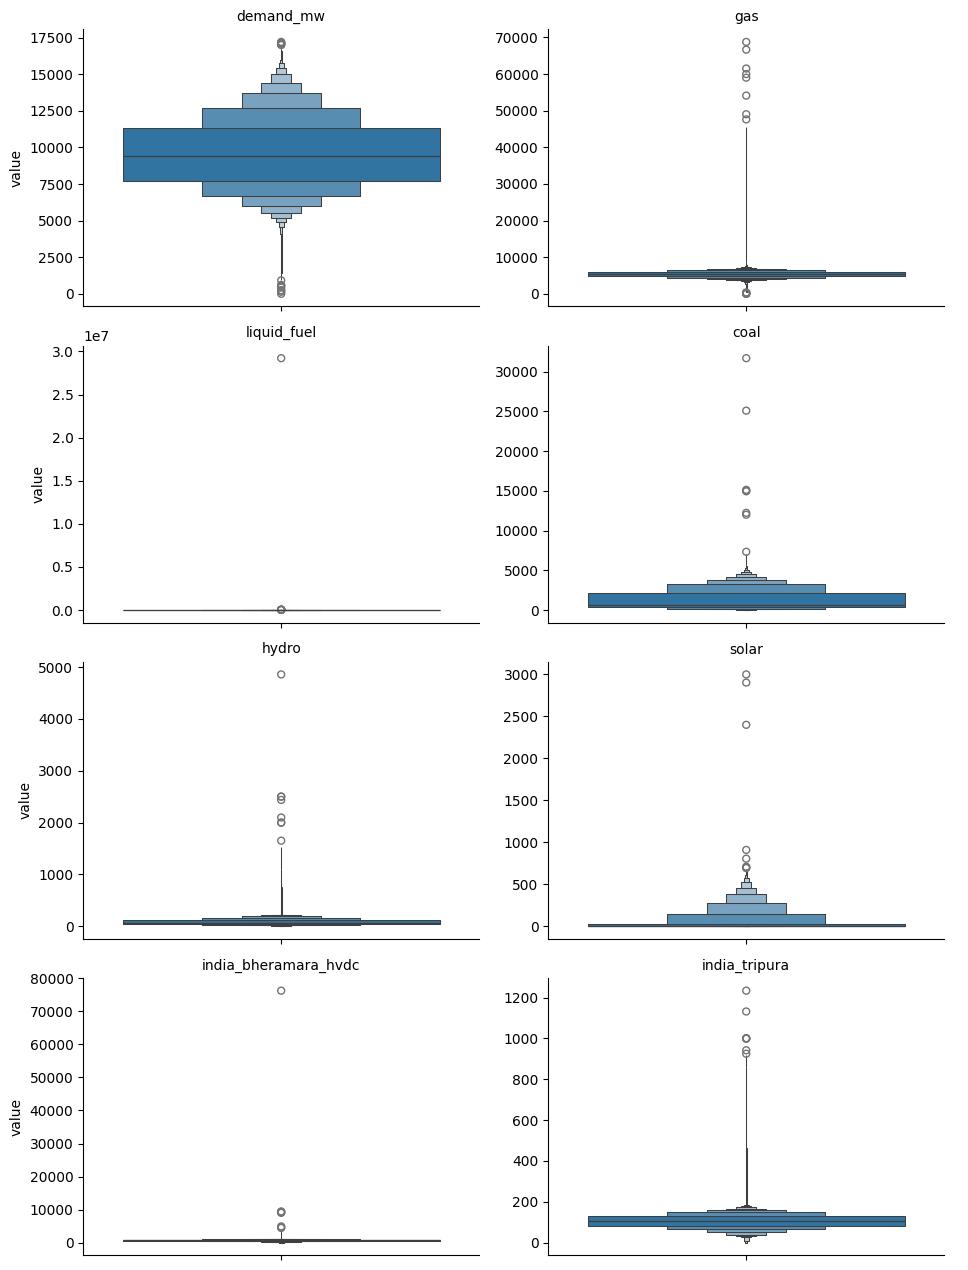

In [64]:
# Visualizing the distribution of the all the columns to check the outliers better 
energy_columns  = df.select_dtypes(include="number").melt(var_name='column', value_name='value')
group = sns.catplot(data=energy_columns,y="value", col="column",kind="boxen", col_wrap= 2, sharey=False, height=3.2, aspect=1.5)
group.set_titles("{col_name}")
plt.show()
# Sources of the code:https://seaborn.pydata.org/generated/seaborn.catplot.html

<h3><center> Feature Engineering<h3>

In [65]:
# let's find average solar by hour to check the peak values
hourly_solar = (df.groupby(df['datetime'].dt.hour)['solar'].agg('mean')).round(2)
hourly_solar

datetime
0       0.18
1       0.33
2       0.12
3       0.24
4       0.11
5       2.81
6      21.65
7      61.44
8     105.78
9     144.72
10    164.69
11    173.36
12    165.98
13    145.87
14    112.36
15     66.75
16     24.44
17      3.72
18      0.10
19      0.19
20      0.13
21      0.10
22      0.12
23      0.17
Name: solar, dtype: float64

In [ ]:
# I am gonna handle the outliers for continuous columns
# the solar is bimodal, because only during the day time it has values.  

columns = [column for column in df.columns if column != 'datetime' and column != 'solar']
q1 = df[columns].quantile(0.25)
q3 = df[columns].quantile(0.75)
upper = q3 + 3 *(q3 - q1)

# Replacing the outliers with nan values and then I will handle the missing values by interpolation.
for column in upper[q3 >q1].index:
    quantity_outliers =(df[column] >upper[column]).sum()
    if quantity_outliers> 0:
        df.loc[df[column] > upper[column], column] = np.nan
        print(f"{column}: clipped extreme {quantity_outliers} outliers, Threshold:{upper[column]:.0f}")

# After clipping the outliers, I will handle the new missing values
df = df.set_index('datetime').interpolate(method='time', limit=3)
fill = df.groupby([df.index.hour, df.index.month]).transform('median')
df = df.fillna(fill).reset_index()
# For debugging,   I used QwEn 

gas: clipped extreme 14 outliers, Threshold: 9909
liquid_fuel: clipped extreme 20 outliers, Threshold: 8356
coal: clipped extreme 7 outliers, Threshold: 7572
hydro: clipped extreme 58 outliers, Threshold: 384
india_bheramara_hvdc: clipped extreme 12 outliers, Threshold: 1886
india_tripura: clipped extreme 37 outliers, Threshold: 282


In [67]:
print(f"Remaining missing: {df.isnull().sum().sum()}")

Remaining missing: 0


### Helper function 

In [68]:
# Like classification task in second assignment, I am gonna build a evaluation funciton 
# To evaluate the original vs optimized DS 
# model's scale uses L2 
def evaluate(X, y, label='', n_splits=5):
    model = make_pipeline(StandardScaler(), Ridge())
    splitter = TimeSeriesSplit(n_splits=n_splits)
    scores = cross_validate(model, X, y, cv=splitter, scoring={'r2': 'r2', 'mae': 'neg_mean_absolute_error'})
    r2 = scores['test_r2']
    mae = -scores['test_mae']
    #  In output is, average r2 and mae with their std
    print(f'[{label}] mean R2: {r2.mean():.3f} ± {r2.std():.3f} *** 'f'mean MAE: {mae.mean():.0f} ± {mae.std():.0f} MW')
    return {'label': label,'r2_mean': r2.mean(), 'r2_std': r2.std(),'mae_mean': mae.mean(), 'mae_std': mae.std()}

In [69]:
feature_column = [column for column in df.columns if column not in ['datetime', 'demand_mw']]
baseline_results = evaluate(df[feature_column], df['demand_mw'], "baseline")
r2_base = baseline_results['r2_mean']
mae_base = baseline_results['mae_mean']

[baseline] mean R2: 0.910 ± 0.054 *** mean MAE: 396 ± 190 MW


### Pearson correlation 

In [70]:
# In this step, I analyze the  pearson correlation with the demand.
correlation = df[feature_column].corrwith(df['demand_mw']).sort_values(ascending=False).round(2)
print("Correlation with demand MW:")
correlation
# Everything is clear and makes sense, what I can see.

Correlation with demand MW:


liquid_fuel             0.62
india_bheramara_hvdc    0.62
coal                    0.61
gas                     0.49
india_tripura           0.29
solar                   0.24
hydro                   0.24
dtype: float64

### Redundancy

In [71]:
# Variance Inflation Factor: 
vif = pd.DataFrame({'feature':feature_column,'VIF':[variance_inflation_factor(
                   df[feature_column].values, i) for i in range(len(feature_column))]}).sort_values('VIF',ascending=False).round(1)
print("Variance Inflation Factor:")
vif
# As I expected, the gas and coal have very high VIF
# I goonna deal with them later.

Variance Inflation Factor:


,feature,VIF
0,gas,25.3
6,india_tripura,19.4
5,india_bheramara_hvdc,18.9
1,liquid_fuel,4.3
3,hydro,3.6
2,coal,3.0
4,solar,1.5


###  Mutual Information, nonlinear relationships

In [72]:
non_linear = mutual_info_regression(df[feature_column], df['demand_mw'], random_state=42)
mutual_scores = pd.Series(non_linear, index=feature_column).sort_values(ascending=False).round(3)
print("Mutual Information scores:")
print(mutual_scores)

Mutual Information scores:
india_bheramara_hvdc    0.470
coal                    0.404
liquid_fuel             0.404
india_tripura           0.360
hydro                   0.249
gas                     0.244
solar                   0.122
dtype: float64


### Random Forest feature importance

In [73]:
random_forest = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
random_forest.fit(df[feature_column],df['demand_mw'])
random_forest_importance = pd.Series(random_forest.feature_importances_, index=feature_column).sort_values(ascending=False).round(3)
print("Random Forest feature importance:")
random_forest_importance

Random Forest feature importance:


india_bheramara_hvdc    0.308
liquid_fuel             0.297
coal                    0.253
gas                     0.129
india_tripura           0.006
hydro                   0.005
solar                   0.001
dtype: float64

In [74]:
# I used 4 feature selection tools, I can combine the results
ranks = pd.DataFrame({  "correlation": correlation.rank(ascending=False),"VIF": vif.set_index('feature')['VIF'].rank(ascending=True),
                       "Matual_Info": mutual_scores.rank(ascending=False), "Random_Forest": random_forest_importance.rank(ascending=False)})

ranks['average_rank'] = ranks.mean(axis=1).round(1)
ranks.sort_values('average_rank')  
# I am not gonna  to drop any of them, instead I will aggregate them
# into combined features during feature engineering.                 

,correlation,VIF,Matual_Info,Random_Forest,average_rank
india_bheramara_hvdc,1.5,5.0,1.0,1.0,2.1
liquid_fuel,1.5,4.0,2.5,2.0,2.5
coal,3.0,2.0,2.5,3.0,2.6
india_tripura,5.0,6.0,4.0,5.0,5.0
hydro,6.5,3.0,5.0,6.0,5.1
gas,4.0,7.0,6.0,4.0,5.2
solar,6.5,1.0,7.0,7.0,5.4


### Cyclical encoding

In [75]:
# I am gonna extract hour, month, and dayofweek from datetime. 
# then the next step will be  encoding them with sin and cos because

# these variables are cyclical:
# hour 23 is next to hour 0, month 12 is next to month 1, and day 6 is next to day 0.
# that makes the time features easier for Ridge to use.

df['hour']= df['datetime'].dt.hour
df['month'] = df['datetime'].dt.month
df['dayofweek'] = df['datetime'].dt.dayofweek

# Encoding:
df['hour_sin']= np.sin(2 * np.pi * df['hour']/ 24)
df['hour_cos']= np.cos(2* np.pi * df['hour']/ 24)
df['month_sin'] = np.sin(2 * np.pi* df['month']/12)
df['month_cos'] = np.cos(2*np.pi *df['month']/ 12)
df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek']/ 7)
df['dow_cos']= np.cos(2 *np.pi* df['dayofweek']/7)

###  Lag Features

In [76]:
# I am gonna add lag features, that tells the model what demand was in the previous hours

df = df.sort_values('datetime').set_index('datetime')
# Changing smoothly hour to hour
df['demand_lag_1'] = df['demand_mw'].shift(1)
# same hour yesterday
df['demand_lag_24']= df['demand_mw'].shift(24)
# same hour last week
df['demand_lag_168'] = df['demand_mw'].shift(168)
# Mean demand over the last 24 hours
df['demand_roll_24']= df['demand_mw'].shift(1).rolling(24).mean()
# changing from 2 hour ago to 1 hour ago.
df['demand_diff']= df['demand_lag_1']-df['demand_mw'].shift(2) 
df = df.reset_index()

# I used lag features and encoding cyclical for stable seasonality from the calendar, and short term memory from recent demand.
# Source: https://scikit-learn.org/stable/auto_examples/applications/plot_time_series_lagged_features.html

### Aggregations

In [77]:
# In previous cell, I mentioned that I will combine the overlapping collumns 

df['import_power'] = df['india_bheramara_hvdc'] + df['india_tripura']
df['fossil_fuel'] = df['gas'] + df['liquid_fuel'] + df['coal']
# How large is solar compared with the total available
df['solar_share'] = df['solar'] / (df['fossil_fuel']+df['solar'] +df['hydro'] + df['import_power']+1)

# fossil fuel usage pattern changes by time of day 
df['fossil_hour'] = df['fossil_fuel'] * df['hour_cos']

df = df.drop(['gas','liquid_fuel','coal','hydro','solar',
             'india_bheramara_hvdc','india_tripura','hour','month','dayofweek'], axis=1)

# Handling the missing values, 
df = df.iloc[168:]

feature_engineering = [column for column in df.columns if column not in ['datetime', 'demand_mw']]
print("Shape after feature engineering:", df.shape)
print(f"Missing value:{df.isnull().sum().sum()}")

# I used QWEN to understand this : MissingDataError,  Since lag needs first 168 rows do not have history
# I did not notice this before.

Shape after feature engineering: (65221, 17)
Missing value:0


In [78]:
# Evaluating feature engineering

engineering_results = evaluate(df[feature_engineering], df['demand_mw'].dropna(), "after engineering")
r2_engineering = engineering_results['r2_mean']
mae_engineering = engineering_results['mae_mean']

# Baseline:
print(f"Baseline: r2={r2_base:.3f}, mae={mae_base:.0f} MW")

[after engineering] mean R2: 0.956 ± 0.023 *** mean MAE: 219 ± 98 MW
Baseline: r2=0.910, mae=396 MW


### PCA Analysis

In [79]:
# Let me check if PCA on the features can compress them without losing info.

supply_columns = ['import_power', 'fossil_fuel', 'solar_share']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[supply_columns])
pca = PCA()
pca.fit(X_scaled)

print("PCA variance on supply columns:")
for i, variance in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {variance:.3f}, cumulative: {sum(pca.explained_variance_ratio_[:i+1]):.3f}")

# Source: https://scikit-learn.org/stable/auto_examples/compose/plot_digits_pipe.html
# From output: I can say, these three columns are somewhat redundant, but not completely. 

PCA variance on supply columns:
PC1: 0.544, cumulative: 0.544
PC2: 0.318, cumulative: 0.862
PC3: 0.138, cumulative: 1.000


In [80]:
# In previous cell, I fit pca cross validation
# Here, I replace 3 features with 2 combined features, let see if it improves the metric.
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_scaled)

# Keeping other columns unchanged
non_supply = [column for column in feature_engineering if column not in supply_columns]
# Building two version  X 
X_raw = df[feature_engineering].values
X_with_pca = np.hstack([df[non_supply].values, X_pca])

evaluate(X_raw, df['demand_mw']," without PCA")
evaluate(X_with_pca, df['demand_mw'], "with PCA replacing")
#  pca does not improve the metric, the metric got worse. 

[ without PCA] mean R2: 0.956 ± 0.023 *** mean MAE: 219 ± 98 MW
[with PCA replacing] mean R2: 0.934 ± 0.022 *** mean MAE: 321 ± 44 MW


{'label': 'with PCA replacing',
 'r2_mean': 0.9338743559144819,
 'r2_std': 0.02240687639690817,
 'mae_mean': 320.6629666451796,
 'mae_std': 44.193014513508125}

### Re-analyze After Engineering

In [81]:
# I want to see which engineered features matter most.

matual_data = df[['demand_mw']+feature_engineering]
mutual_final = mutual_info_regression(matual_data[feature_engineering],matual_data['demand_mw'],random_state=42)
mutual_final = pd.Series(mutual_final, index=feature_engineering).sort_values(ascending=False).round(3)
mutual_final

fossil_fuel       1.974
demand_lag_1      1.808
demand_lag_24     1.204
fossil_hour       1.112
demand_roll_24    0.838
demand_lag_168    0.826
import_power      0.452
month_cos         0.181
demand_diff       0.115
solar_share       0.103
month_sin         0.095
hour_sin          0.071
hour_cos          0.030
dow_sin           0.006
dow_cos           0.003
dtype: float64

In [82]:
# Let' see again, if my aggregation handled the multicollinearity.

vif_final = pd.DataFrame({'feature':feature_engineering,
                         'VIF':[variance_inflation_factor(df[feature_engineering].values, i)
                          for i in range(len(feature_engineering))]}).sort_values('VIF',ascending=False).round(1)

print("VIF on final features:")
vif_final
# lag columns have high vif, because they have same history. 

VIF on final features:


,feature,VIF
9,demand_roll_24,320.3
6,demand_lag_1,303.3
12,fossil_fuel,199.2
7,demand_lag_24,186.1
8,demand_lag_168,58.4
11,import_power,24.5
14,fossil_hour,23.6
1,hour_cos,20.4
0,hour_sin,2.4
13,solar_share,2.4


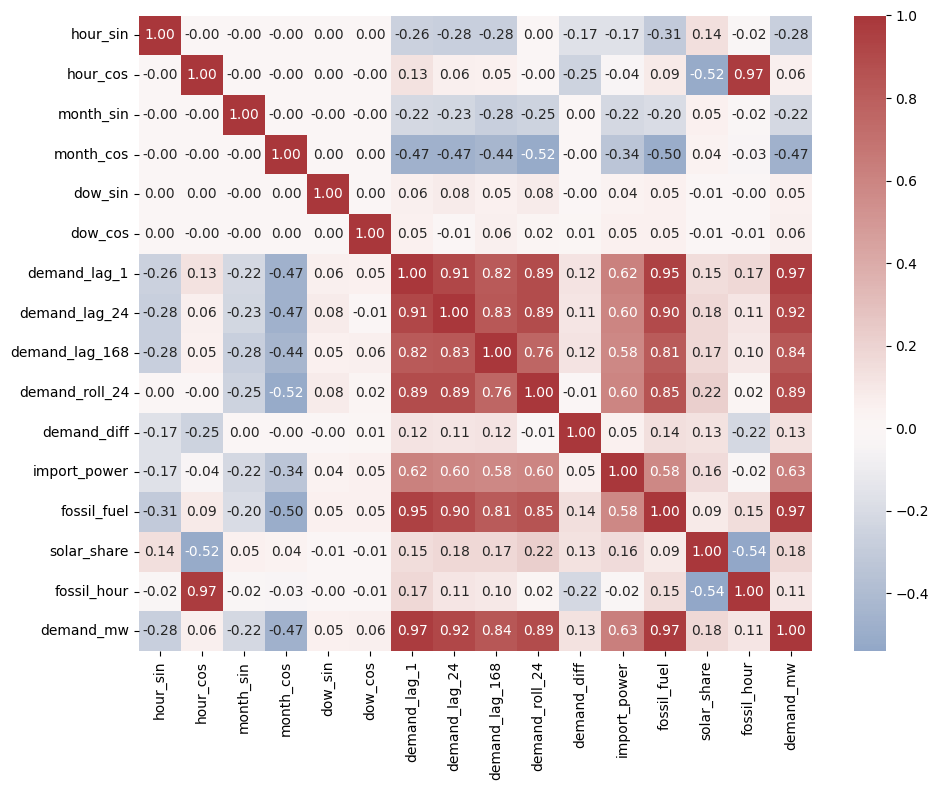

In [83]:
# Correlation heatmap 
plt.figure(figsize=(10, 8))
sns.heatmap(df[feature_engineering + ['demand_mw']].corr().round(2), annot=True, cmap='vlag', center=0, fmt='.2f')
plt.tight_layout()
plt.show()
# demand_lag_1 has the highest correlation with demand mw, which makes sense. 

In [84]:
# I can drop days of week from feature engineering and compare the metric
# Because both columns got less score in mutualinfo. 
feature_engineering  = [column for column in feature_engineering if column not in ['dow_sin', 'dow_cos',]]
evaluate(df[feature_engineering], df['demand_mw'], "after dropping")
# Baseline:
print(f"Baseline:r2={r2_base:.3f}, mae={mae_base:.0f} MW")

[after dropping] mean R2: 0.956 ± 0.023 *** mean MAE: 219 ± 99 MW
Baseline:r2=0.910, mae=396 MW


<h3><center> Comparing Original vs Optimized DS<h3>

In [85]:
# let me align the original and optimized ds for comparison

df_original_2018 = df_original[df_original['datetime'].dt.year >= 2018].reset_index(drop=True)
original_features = [column for column in df_original_2018.columns if column not in ['datetime','demand_mw','remarks','nepal','india_adani','wind','generation_mw','load_shedding']]
print(f"Original: {df_original_2018.shape[0]} rows, features: {original_features}\n")
print(f"Optimized: {df.shape[0]} rows, features: {feature_engineering}")

Original: 68015 rows, features: ['gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'india_bheramara_hvdc', 'india_tripura']

Optimized: 65221 rows, features: ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'demand_lag_1', 'demand_lag_24', 'demand_lag_168', 'demand_roll_24', 'demand_diff', 'import_power', 'fossil_fuel', 'solar_share', 'fossil_hour']


In [86]:
# First thing,  I should check, did I damage the target distribution?
# If mean, std, quartiles changed a lot, that means my cleaning damaged the ds 

compare = pd.DataFrame({'Original':df_original_2018['demand_mw'].describe(),'Optimized': df['demand_mw'].describe()}).round(1)
print("Demand energy distribution comparison:")
print(compare)
# I can say: the distributions are very close

Demand energy distribution comparison:
       Original  Optimized
count   68015.0    65221.0
mean     9652.8     9596.2
std      2669.5     2469.3
min         6.0        6.0
25%      7782.0     7724.0
50%      9464.0     9405.0
75%     11406.0    11350.0
max    156050.0    17200.0


In [87]:
# Model comparison: 

# ridge on original features vs optimized features.
# I use the same rows for both to make it a fair test.

df_original_aligned= df_original_2018.iloc[-len(df):].reset_index(drop=True)
df_original_aligned = df_original_aligned[original_features].fillna(df_original_aligned[original_features].median())

original_results= evaluate(df_original_aligned, df['demand_mw'], "original features")
optimized_results= evaluate(df[feature_engineering], df['demand_mw'], "optimized features")
# the model has terrible results on original DS 
# the result for optimized ds is very good and has small spread means, I can say, the model stays stable across the splits.
# Average miss is not bad, only 219 MW is not big friction.

[original features] mean R2: -17.831 ± 34.382 *** mean MAE: 2116 ± 502 MW
[optimized features] mean R2: 0.956 ± 0.023 *** mean MAE: 219 ± 99 MW


In [88]:
# In this cell, I am gonna train model and check the residuals
X = df[feature_engineering].values
y = df['demand_mw'].values

# 20 % for testing 
split_idx = int(len(df) * 0.80)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

model = make_pipeline(StandardScaler(), Ridge())
model.fit(X_train, y_train)
predicted_demand = model.predict(X_test)
residuals = y_test - predicted_demand

print(f"Residual: mean={residuals.mean():.1f} MW, std={residuals.std():.1f} MW")
print(f"mape on test: {np.mean(np.abs(residuals) / y_test)*100:.2f}%")
# Model has acceptable mape percentage and small underprediction biased.

Residual: mean=202.5 MW, std=513.5 MW
mape on test: 4.36%


In [ ]:
# What I did:
# Exploring the data, handled missing values, wrong entries for demand both high and low.
# tried 4 feature selection tools and ranked the features.
# Feature engineering: cyclical encoding, lag features, aggregations.
# tested pca on supply features, but it did not improve the metric
# re-analyzing after engineering with lag features.

# Realism check:
# The optimized ds distribution is close to the original ds. 